# Разработка пользовательских функций

По желанию пользователь может разрабатывать и тестировать новые алгоритмы и функции.

Для этого необходимо создать класс-функцию наследующую от соответсвующего базового класса-функции (в зависимости от поставленной задачи)

В Генезис реализованы следующие базовые классы:

| Базовый Класс-функция | Описание |
|--------------------|----------|
| [`MetricBase`](405_base_classes.qmd#metricbase) | Метрики |
| [`StateBase`](405_base_classes.qmd#statebase) | Состояние |
| [`BestPointsBase`](405_base_classes.qmd#bestpointsbase) | Алгоритм BLP |
| [`MCLPBase`](405_base_classes.qmd#mclpbase) | Алгоритм MCLP |
| [`StopCaseBase`](405_base_classes.qmd#stopcasebase) | Функция остановки |
| [`PointSelectorBase`](405_base_classes.qmd#pointselectorbase) | Селектор новых узлов |
| [`LSCPBase`](405_base_classes.qmd#lscpbase) | Алгоритм LSCP |

## Пример реализации алгоритма BLP

В качестве примера рассмотри создание алгоритма поиска лучшего узла графа методом рекурсивного деления области на квадраты.

Логика алгоритма будет следующая:

Дан граф улично-дорожной сети в формате `networkx.MultiDiGraph`, веса ребер определены полем `travel_time` и представляют время следования по участку дороги в минутах. 

Алгоритм:

1. Граф проецируется в локальную систему координат при помощи `osmnx.project_graph`
2. Определяется основной прямоугольник `P` в который вписаны все узлы графа
3. Основной прямоугольник разбивается на некоторое количество квадратов меньшего размера. Размер стороны квадратов определется как половина наименьшего измерения прямоугольника `P`
4. В пределах каждого из меньших квадратов определяется `n` узлов, для каждого из них при помощи `genesis.Best_points.NodeMetric` определяется значение метрики времени среднего времени прибытия `genesis.metrics.ArrivalTime`
5. Выбирается квадрат в пределах которого находится узел с наилучшей метрикой
6. Если в пределах квадрата содержится больше узлов чем некоторое минимальное значение `n_min_count` задаваемое как гиперпараметр алгоритма, то шаги 4,5,6 повторяются
7. Алгоритм возвращает узел с лучшей метрикой

Алгоритм должен реализован как наследник класса `genesis.core.BestPointsBase` и реализует соответсвующий интерфейс.

Подключение необходимых библиотек

In [33]:
import networkx as nx
import numpy as np
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely

Загрузка исходных данных

In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

Реализация алгоритма

In [ ]:
import random
import math
from genesis.core import BestPointsBase, StateBase, MetricBase
from genesis.best_points import NodeMetric
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState


class BestNodeSquareZoom(BestPointsBase):
    """
    Поиск лучшего узла графа методом рекурсивного деления области на квадраты.
    1. Проекция графа в локальную систему координат.
    2. Определение главного прямоугольника, в который вписаны узлы графа.
    3. Разбиение прямоугольника на квадраты со стороной min(width, height)/2.
    4. В каждом квадрате случайная выборка до n узлов и вычисление метрики.
    5. Выбор квадрата с узлом наилучшей метрики и рекурсия, пока количество узлов в квадрате не <= n_min_count.
    """
    def __init__(self, state_function: StateBase,
                metric_function: MetricBase,
                n_samples: int = 10,
                n_min_count: int = 5,
                **kwargs):
        """
        `state_function`: StateBase — функция расчета состояния окружения.
        `metric_function`: MetricBase — функция расчета метрики.
        `n_samples`: int — максимальное число узлов для оценки в каждом квадрате.
        `n_min_count`: int — минимальное число узлов для останова рекурсии.
        """
        self.n_samples = n_samples
        self.n_min_count = n_min_count
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env: nx.Graph,
                area=None, 
                start_point: int = None,
                points_list: set = None,
                **kwargs) -> tuple[int | None, float | None]:
        """
        `env`: MultiDiGraph — граф улично-дорожной сети.
        `area`: pandas.Series — маска узлов графа для расчёта доступности (см. NodeMetric).
        `start_point`: не используется.
        `points_list`: set — начальный набор узлов-кандидатов.
        Возвращает `(best_node, best_metric)`.
        """
        # Подготовка исходных узлов
        if points_list is None:
            current_nodes = list(env.nodes())
        else:
            current_nodes = list(points_list)
        # Проекция графа
        # Проекция графа только если он в географической системе координат
        if env.graph['crs'] == 'epsg:4326':
            G = ox.project_graph(env)
        else:
            G = env
        node_metric_fn = NodeMetric(self.state_function, self.metric_function)
        best_node = None
        best_metric = None

        level = 1
        best_squares = []
        while True:
            # Ограничиваем текущие узлы маской area, если задана
            if area is not None:
                current_nodes = [u for u in current_nodes if area.get(u, False)]
            if not current_nodes:
                return None, None
            # Координаты узлов
            xs = [G.nodes[u]['x'] for u in current_nodes]
            ys = [G.nodes[u]['y'] for u in current_nodes]
            x_min, x_max = min(xs), max(xs)
            y_min, y_max = min(ys), max(ys)
            dx, dy = x_max - x_min, y_max - y_min
            size = min(dx, dy) / 2
            # Создание квадратов
            nx_squares = int(math.ceil(dx / size))
            ny_squares = int(math.ceil(dy / size))
            squares = []
            for i in range(nx_squares):
                for j in range(ny_squares):
                    x0, y0 = x_min + i * size, y_min + j * size
                    squares.append((x0, y0, x0 + size, y0 + size))
            # Оценка квадратов
            best_node_sq = None
            best_metric_sq = None
            best_square_nodes = None
            square = 1
            best_squares_in_square = None
            for x0, y0, x1, y1 in squares:
                # Узлы в квадрате
                nodes_sq = [u for u in current_nodes if x0 <= G.nodes[u]['x'] <= x1 and y0 <= G.nodes[u]['y'] <= y1]
                if not nodes_sq:
                    continue
                # Выборка узлов
                if len(nodes_sq) > self.n_samples:
                    sample = random.sample(nodes_sq, self.n_samples)
                else:
                    sample = nodes_sq
                # Оценка узлов
                for u in sample:
                    node_metric = node_metric_fn(env=G, node=u, area=area, **kwargs)
                    if node_metric is None:
                        continue
                    if best_metric_sq is None or self.metric_function.compare(node_metric, best_metric_sq) == node_metric:
                        best_metric_sq = node_metric
                        best_node_sq = u
                        best_square_nodes = nodes_sq
                        best_squares_in_square = (x0, y0, x1, y1)
                print(f'square {square} - {best_node_sq}, {best_metric_sq}')
                square += 1
            best_squares.append(best_squares_in_square)
            if best_node_sq is None:
                break
            best_node, best_metric = best_node_sq, best_metric_sq
            # Проверка условия останова
            if len(best_square_nodes) <= self.n_min_count:
                break
            # Переход к узлам лучшего квадрата
            current_nodes = best_square_nodes
            # Печать результата
            print(f'level {level} - {best_node}, {best_metric}')
            level += 1

        return best_node, best_metric, best_squares

:::{.callout-important}

В данном случае функционал алгоритма был расширен за счет добавления в перечень возвращаемых переменных списка квадратов в пределах которых обнаружен лучший узел.

Это сделано для визуализации хода расчета и отладки. В готовых решениях изменение перечня возвращаемых аргументов строго воспрещено логикой и будет приводить к ошибке при использовании алгоритма в составе гибридных решений.

:::

square 1 - 10731791184, 16.59093751929235
square 2 - 10731791184, 16.59093751929235
square 3 - 10731791184, 16.59093751929235
square 4 - 10731791184, 16.59093751929235
square 5 - 10731791184, 16.59093751929235
square 6 - 10731791184, 16.59093751929235
level 1 - 10731791184, 16.59093751929235
square 1 - 775453060, 28.338463824106277
square 2 - 5084974091, 22.200625880473066
square 3 - 390615908, 20.29736344874703
square 4 - 1432526171, 15.506545978847514
square 5 - 1432526171, 15.506545978847514
level 2 - 1432526171, 15.506545978847514
square 1 - 2537678942, 20.263088896759616
square 2 - 10941191746, 18.7696212272216
square 3 - 10595884338, 16.92572271200879
square 4 - 12200773782, 15.484790316849084
square 5 - 12200773782, 15.484790316849084
level 3 - 12200773782, 15.484790316849084
square 1 - 1515032972, 15.219339346913326
square 2 - 1515032972, 15.219339346913326
square 3 - 1515032972, 15.219339346913326
square 4 - 1515032972, 15.219339346913326
square 5 - 1515032972, 15.219339346913

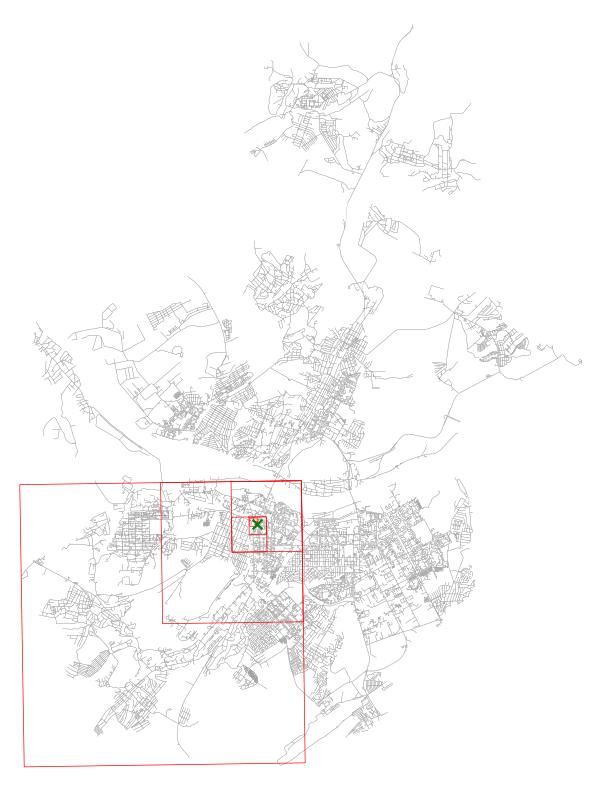

In [38]:
# Инициализация алгоритма
blp = BestNodeSquareZoom(
    state_function  = FirstArrivalUnitState(),
    metric_function = ArrivalTime(),
    n_samples       = 10,
    n_min_count     = 10,
    )

# Расчет лучшего размещения
best_node, best_metric, best_squares = blp(G)


# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')


# Визуализация ГДС с оптимальной точкой размещения и квадратами последовательного приближения
geometry = [shapely.geometry.box(x0, y0, x1, y1) for x0, y0, x1, y1 in best_squares]

boxes = gpd.GeoDataFrame(geometry, columns=['geometry'], crs=ox.project_graph(G).graph['crs'])
boxes = ox.projection.project_gdf(boxes, to_latlong=True)

fig, ax = plt.subplots(figsize=(10, 10))
ox.plot_graph(G, ax=ax, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
boxes.boundary.plot(ax=ax, color='red', linewidth=0.5)
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='g', marker='x', 
                                                       markersize=50, zorder=10)
plt.show()

Проверка расчета для метрики ИП-10.

Дополнительно используем функцию `genesis.untils.timing` для вывода времени ваыполнения алгоритма.

square 1 - 10560741809, 25.791531303342328
square 2 - 10560741809, 25.791531303342328
square 3 - 10560741809, 25.791531303342328
square 4 - 12240751488, 32.86162656241397
square 5 - 12240751488, 32.86162656241397
square 6 - 12240751488, 32.86162656241397
level 1 - 12240751488, 32.86162656241397
square 1 - 7005955871, 8.264963383073619
square 2 - 12333912009, 27.212157920819337
square 3 - 12240751495, 32.87814547657067
square 4 - 12240751495, 32.87814547657067
square 5 - 12240751495, 32.87814547657067
square 6 - 12240751495, 32.87814547657067
level 2 - 12240751495, 32.87814547657067
square 1 - 10669461560, 31.308848631683276
square 2 - 10669461560, 31.308848631683276
square 3 - 5619329469, 31.319861241121085
square 4 - 5619329469, 31.319861241121085
square 5 - 5619329469, 31.319861241121085
square 6 - 5619329469, 31.319861241121085
level 3 - 5619329469, 31.319861241121085
square 1 - 9107440367, 33.01580309454325
square 2 - 9107440367, 33.01580309454325
square 3 - 9107440367, 33.01580309

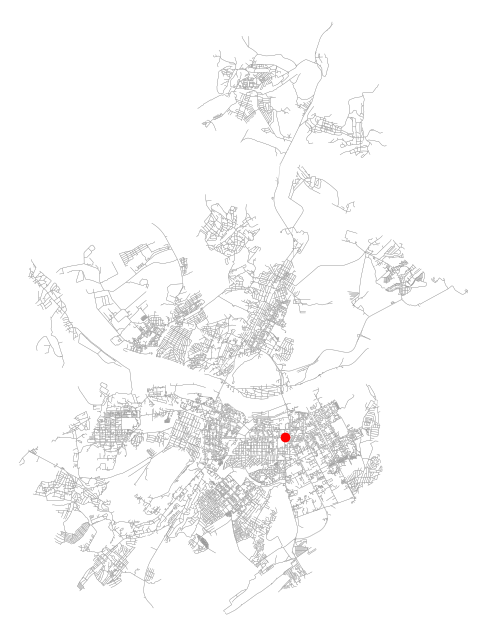

In [39]:
# Использование алгоритма Обезьяньего поиска
from genesis.metrics import CoverIndex
from genesis.utils import timing

blp = timing(BestNodeSquareZoom(
    state_function  = FirstArrivalUnitState(),
    metric_function = CoverIndex(),
    n_samples       = 10,
    n_min_count     = 5,
    ))

# Расчет лучшего размещения
best_node, best_metric, _ = blp(env=G)

# Печать результата
print('Наиболее выгодная точка размещения:', best_node)
print('Среднее время следования в любую точку города:', best_metric, 'мин')

# Визуализация ГДС с оптимальной точкой размещения
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.2, show=False, close=False, bgcolor='white')
ox.graph_to_gdfs(G, edges=False).loc[[best_node]].plot(ax=ax, color='red');